# Project

## Milestone 1: Data Collection

In [3]:
import requests
import pandas as pd

# Your TMDb API key
api_key = "4b288d5464e7f4201453180dac7c83a0"

# Base URL for popular movies
base_url = "https://api.themoviedb.org/3/movie/popular"
genre_url = "https://api.themoviedb.org/3/genre/movie/list"
language = "en-US"

# Function to fetch genres
def fetch_genres(api_key):
    response = requests.get(f"{genre_url}?api_key={api_key}&language={language}")
    if response.status_code == 200:
        genres = response.json().get("genres", [])
        return {genre["id"]: genre["name"] for genre in genres}
    else:
        print(f"Failed to fetch genres: {response.status_code}")
        return {}

# Function to fetch movies with genre names
def fetch_movies(api_key, genre_mapping, total_pages=50):
    all_movies = []
    for page in range(1, total_pages + 1):
        url = f"{base_url}?api_key={api_key}&language={language}&page={page}"
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            for movie in data.get("results", []):
                genre_names = [genre_mapping.get(genre_id, "Unknown") for genre_id in movie.get("genre_ids", [])]
                all_movies.append({
                    "Movie Title": movie.get("title"),
                    "Genres": ", ".join(genre_names),
                    "Release Year": movie.get("release_date", "").split("-")[0],
                    "IMDb Rating": movie.get("vote_average"),
                    "Number of User Votes": movie.get("vote_count"),
                    "Movie Description": movie.get("overview"),
                    "Poster URL": f"https://image.tmdb.org/t/p/w500{movie['poster_path']}" if movie.get("poster_path") else None
                })
        else:
            print(f"Failed to fetch page {page}: {response.status_code}")
    return all_movies

# Fetch genre mapping
genre_mapping = fetch_genres(api_key)

# Fetch movies
movies_data = fetch_movies(api_key, genre_mapping)

# Save to CSV
df = pd.DataFrame(movies_data)
csv_path = "movies_dataset_with_genre_names.csv"
df.to_csv(csv_path, index=False)
print(f"Data for {len(df)} movies saved to {csv_path}")





Data for 1000 movies saved to movies_dataset_with_genre_names.csv


In [7]:
df

,Movie Title,Genres,Release Year,IMDb Rating,Number of User Votes,Movie Description,Poster URL
0,Venom: The Last Dance,"Action, Science Fiction, Adventure",2024,6.700,1315,Eddie and Venom are on the run. Hunted by both...,https://image.tmdb.org/t/p/w500/aosm8NMQ3UyoBV...
1,Moana 2,"Animation, Adventure, Family, Comedy",2024,6.900,452,After receiving an unexpected call from her wa...,https://image.tmdb.org/t/p/w500/yh64qw9mgXBvla...
2,Elevation,"Action, Science Fiction, Thriller",2024,6.400,140,A single father and two women venture from the...,https://image.tmdb.org/t/p/w500/uQhYBxOVFU6s9a...
3,Absolution,"Action, Crime, Thriller",2024,6.119,126,An aging ex-boxer gangster working as muscle f...,https://image.tmdb.org/t/p/w500/cNtAslrDhk1i3I...
4,Armor,"Action, Crime, Thriller",2024,5.600,60,Armored truck security guard James Brody is wo...,https://image.tmdb.org/t/p/w500/pnXLFioDeftqjl...
...,...,...,...,...,...,...,...
995,Desire,"Drama, Romance",2011,6.300,1229,In a social context deteriorated by a countryw...,https://image.tmdb.org/t/p/w500/wxvvNXY3n0637c...
996,Ace,Comedy,1981,6.142,211,"Asso (Ace), the best poker-player in town, was...",https://image.tmdb.org/t/p/w500/2fh2vkNEQ0dPeS...
997,Naruto Shippuden the Movie: The Will of Fire,"Action, Adventure, Comedy, Drama, Fantasy, Ani...",2009,7.319,459,Ninjas with bloodline limits begin disappearin...,https://image.tmdb.org/t/p/w500/pZzdFmztwmg0FU...
998,Project X,Comedy,2012,6.882,6349,Three high school seniors throw a party to mak...,https://image.tmdb.org/t/p/w500/lUPDGT3lyRrq8S...


## Milestone 2: Data Cleaning and Preprocessing

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler


In [9]:
missing_summary = df.isnull().sum()  # Count missing values in each column

print("Missing Values Summary:")
print(missing_summary)

Missing Values Summary:
Movie Title             0
Genres                  0
Release Year            0
IMDb Rating             0
Number of User Votes    0
Movie Description       0
Poster URL              0
dtype: int64


In [10]:
# 1. Add normalized columns for numerical features
scaler = MinMaxScaler()
df["Normalized IMDb Rating"] = scaler.fit_transform(df[["IMDb Rating"]])
df["Normalized Number of User Votes"] = scaler.fit_transform(df[["Number of User Votes"]])


In [11]:
df

,Movie Title,Genres,Release Year,IMDb Rating,Number of User Votes,Movie Description,Poster URL,Normalized IMDb Rating,Normalized Number of User Votes
0,Venom: The Last Dance,"Action, Science Fiction, Adventure",2024,6.700,1315,Eddie and Venom are on the run. Hunted by both...,https://image.tmdb.org/t/p/w500/aosm8NMQ3UyoBV...,0.6700,0.035892
1,Moana 2,"Animation, Adventure, Family, Comedy",2024,6.900,452,After receiving an unexpected call from her wa...,https://image.tmdb.org/t/p/w500/yh64qw9mgXBvla...,0.6900,0.012337
2,Elevation,"Action, Science Fiction, Thriller",2024,6.400,140,A single father and two women venture from the...,https://image.tmdb.org/t/p/w500/uQhYBxOVFU6s9a...,0.6400,0.003821
3,Absolution,"Action, Crime, Thriller",2024,6.119,126,An aging ex-boxer gangster working as muscle f...,https://image.tmdb.org/t/p/w500/cNtAslrDhk1i3I...,0.6119,0.003439
4,Armor,"Action, Crime, Thriller",2024,5.600,60,Armored truck security guard James Brody is wo...,https://image.tmdb.org/t/p/w500/pnXLFioDeftqjl...,0.5600,0.001638
...,...,...,...,...,...,...,...,...,...
995,Desire,"Drama, Romance",2011,6.300,1229,In a social context deteriorated by a countryw...,https://image.tmdb.org/t/p/w500/wxvvNXY3n0637c...,0.6300,0.033544
996,Ace,Comedy,1981,6.142,211,"Asso (Ace), the best poker-player in town, was...",https://image.tmdb.org/t/p/w500/2fh2vkNEQ0dPeS...,0.6142,0.005759
997,Naruto Shippuden the Movie: The Will of Fire,"Action, Adventure, Comedy, Drama, Fantasy, Ani...",2009,7.319,459,Ninjas with bloodline limits begin disappearin...,https://image.tmdb.org/t/p/w500/pZzdFmztwmg0FU...,0.7319,0.012528
998,Project X,Comedy,2012,6.882,6349,Three high school seniors throw a party to mak...,https://image.tmdb.org/t/p/w500/lUPDGT3lyRrq8S...,0.6882,0.173290


In [12]:
# 2. Add one-hot encoded columns for genres
genre_dummies = df["Genres"].str.get_dummies(sep=", ")
df = pd.concat([df, genre_dummies], axis=1)
df

,Movie Title,Genres,Release Year,IMDb Rating,Number of User Votes,Movie Description,Poster URL,Normalized IMDb Rating,Normalized Number of User Votes,Action,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,Venom: The Last Dance,"Action, Science Fiction, Adventure",2024,6.700,1315,Eddie and Venom are on the run. Hunted by both...,https://image.tmdb.org/t/p/w500/aosm8NMQ3UyoBV...,0.6700,0.035892,1,...,0,0,0,0,0,1,0,0,0,0
1,Moana 2,"Animation, Adventure, Family, Comedy",2024,6.900,452,After receiving an unexpected call from her wa...,https://image.tmdb.org/t/p/w500/yh64qw9mgXBvla...,0.6900,0.012337,0,...,0,0,0,0,0,0,0,0,0,0
2,Elevation,"Action, Science Fiction, Thriller",2024,6.400,140,A single father and two women venture from the...,https://image.tmdb.org/t/p/w500/uQhYBxOVFU6s9a...,0.6400,0.003821,1,...,0,0,0,0,0,1,0,1,0,0
3,Absolution,"Action, Crime, Thriller",2024,6.119,126,An aging ex-boxer gangster working as muscle f...,https://image.tmdb.org/t/p/w500/cNtAslrDhk1i3I...,0.6119,0.003439,1,...,0,0,0,0,0,0,0,1,0,0
4,Armor,"Action, Crime, Thriller",2024,5.600,60,Armored truck security guard James Brody is wo...,https://image.tmdb.org/t/p/w500/pnXLFioDeftqjl...,0.5600,0.001638,1,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Desire,"Drama, Romance",2011,6.300,1229,In a social context deteriorated by a countryw...,https://image.tmdb.org/t/p/w500/wxvvNXY3n0637c...,0.6300,0.033544,0,...,0,0,0,0,1,0,0,0,0,0
996,Ace,Comedy,1981,6.142,211,"Asso (Ace), the best poker-player in town, was...",https://image.tmdb.org/t/p/w500/2fh2vkNEQ0dPeS...,0.6142,0.005759,0,...,0,0,0,0,0,0,0,0,0,0
997,Naruto Shippuden the Movie: The Will of Fire,"Action, Adventure, Comedy, Drama, Fantasy, Ani...",2009,7.319,459,Ninjas with bloodline limits begin disappearin...,https://image.tmdb.org/t/p/w500/pZzdFmztwmg0FU...,0.7319,0.012528,1,...,0,0,0,0,0,0,0,0,0,0
998,Project X,Comedy,2012,6.882,6349,Three high school seniors throw a party to mak...,https://image.tmdb.org/t/p/w500/lUPDGT3lyRrq8S...,0.6882,0.173290,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# 3. Check and remove duplicate entries (if any)
duplicates_count = df.duplicated().sum()
print(duplicates_count )

77


In [14]:
df.drop_duplicates(inplace=True)
duplicates_count = df.duplicated().sum()
print(duplicates_count )

0


## Milestone 3: Exploratory Data Analysis (EDA)

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [16]:
# Basic statistics
statistics = df.describe()
statistics


,IMDb Rating,Number of User Votes,Normalized IMDb Rating,Normalized Number of User Votes,Action,Adventure,Animation,Comedy,Crime,Documentary,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,...,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,6.724733,5088.088841,0.672473,0.138875,0.396533,0.279523,0.173348,0.274106,0.124594,0.005417,...,0.034670,0.145179,0.009751,0.050921,0.145179,0.172264,0.014085,0.255688,0.031419,0.004334
std,1.414224,6924.812655,0.141422,0.189006,0.489443,0.449008,0.378753,0.446305,0.330437,0.073441,...,0.183041,0.352472,0.098317,0.219955,0.352472,0.377815,0.117903,0.436484,0.174543,0.065724
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.300000,99.500000,0.630000,0.002716,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.929000,1671.000000,0.692900,0.045608,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.500000,7957.500000,0.750000,0.217193,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,10.000000,36638.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


###  Визуализации

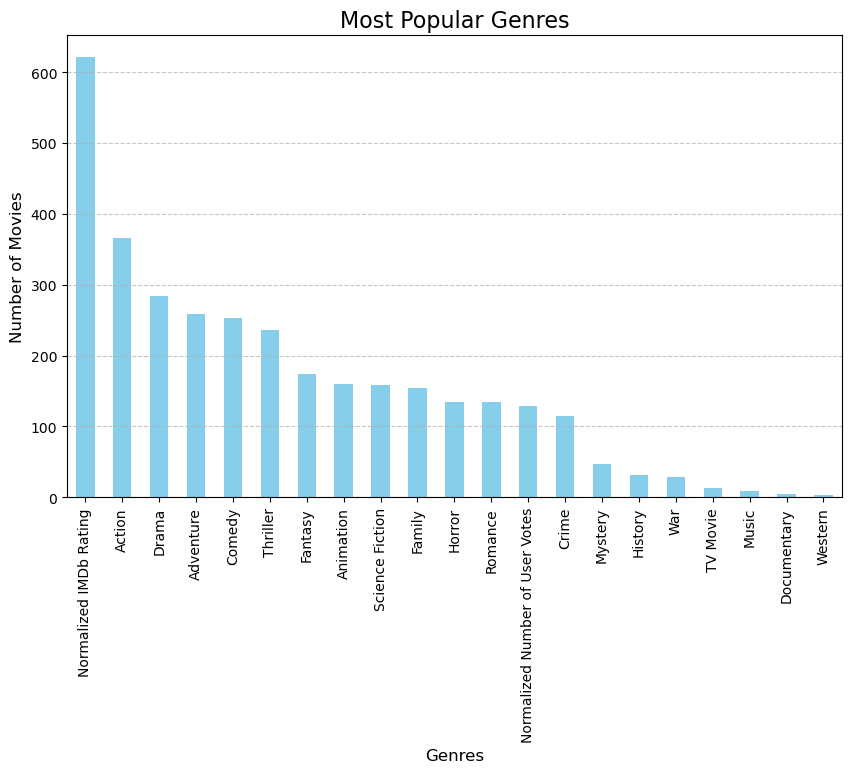

In [17]:
# Summing up the number of movies for each genre
genre_counts = df.iloc[:, 7:].sum().sort_values(ascending=False)  # Genre columns start from the 7th column
plt.figure(figsize=(10, 6))
genre_counts.plot(kind="bar", color="skyblue")
plt.title("Most Popular Genres", fontsize=16)
plt.ylabel("Number of Movies", fontsize=12)
plt.xlabel("Genres", fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


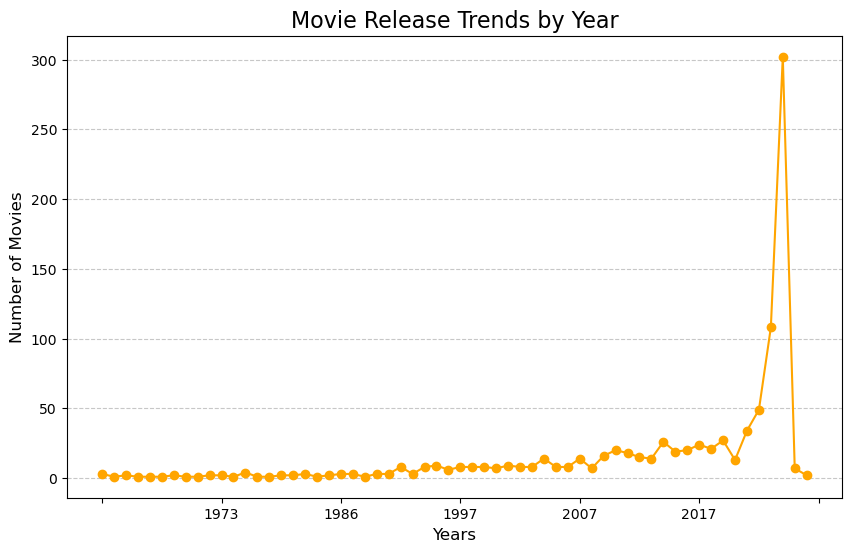

In [18]:
# Counting the number of movies for each year
release_trends = df["Release Year"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
release_trends.plot(kind="line", color="orange", marker="o")
plt.title("Movie Release Trends by Year", fontsize=16)
plt.ylabel("Number of Movies", fontsize=12)
plt.xlabel("Years", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


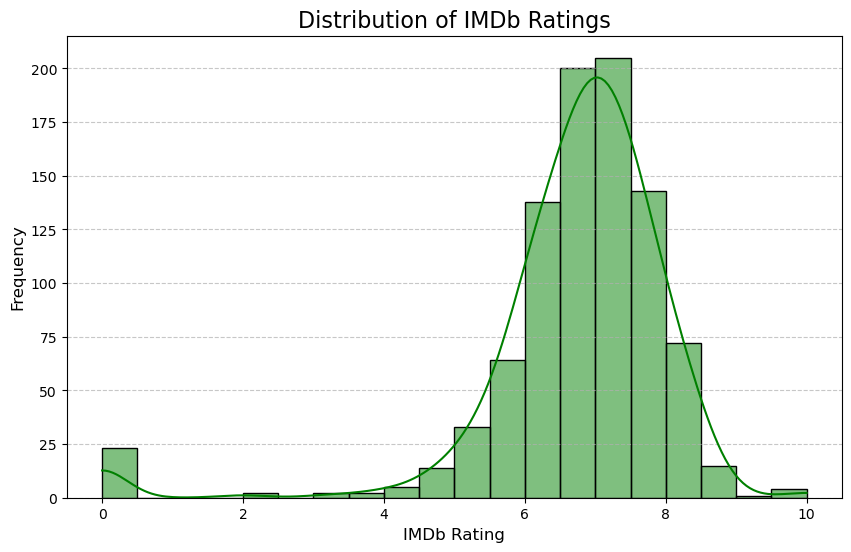

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df["IMDb Rating"], bins=20, kde=True, color="green")
plt.title("Distribution of IMDb Ratings", fontsize=16)
plt.xlabel("IMDb Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


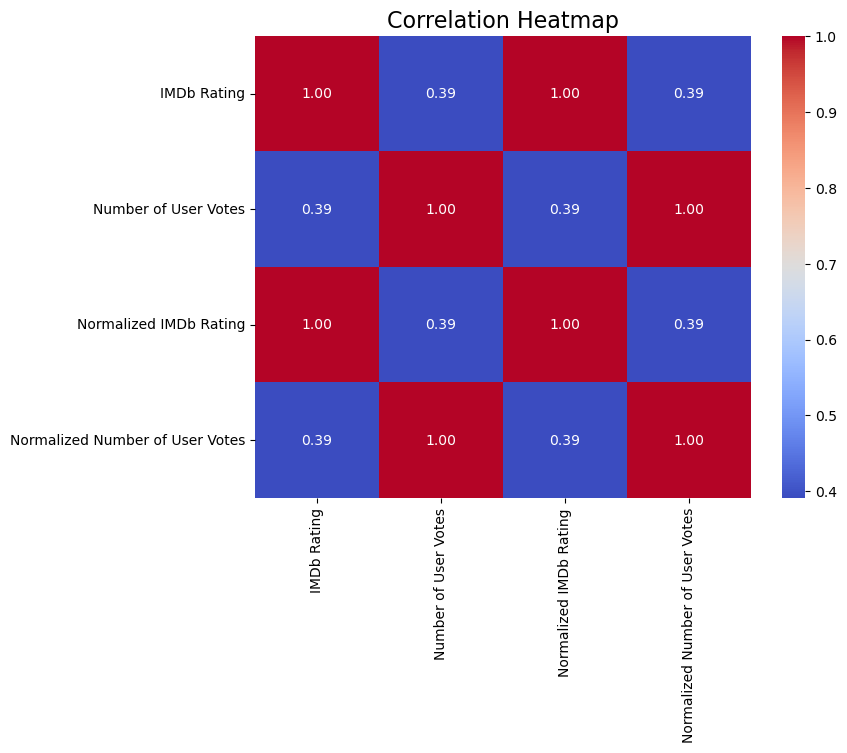

In [20]:
# Calculating correlation only for numeric columns
correlation_matrix = df[["IMDb Rating", "Number of User Votes", "Normalized IMDb Rating", "Normalized Number of User Votes"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap", fontsize=16)
plt.show()



## Milestone 4: Linear Regression Model for Rating Prediction

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import pandas as pd

# Load the original dataset
df = pd.read_csv('movies_dataset_with_genre_names.csv')

# Save a copy of the original data
df_original = df.copy()

# 2. Handle missing values
imputer = SimpleImputer(strategy='mean')
df[['Release Year', 'Number of User Votes', 'IMDb Rating']] = imputer.fit_transform(df[['Release Year', 'Number of User Votes', 'IMDb Rating']])

# 3. Split the data into features (X) and target variable (y)
X = df[['Release Year', 'Number of User Votes']]
y = df['IMDb Rating']

# 4. Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Split the data into training and testing sets (80-20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 6. Create and train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 7. Make predictions on the test set
y_pred = model.predict(X_test)

# 8. Evaluate the model using metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

# Print the metrics
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared (R2): {r2}')



Mean Absolute Error (MAE): 0.8080172342899681
Mean Squared Error (MSE): 1.8281752280749106
Root Mean Squared Error (RMSE): 1.3521003025200868
R-squared (R2): 0.150566682033072


/Library/Java/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


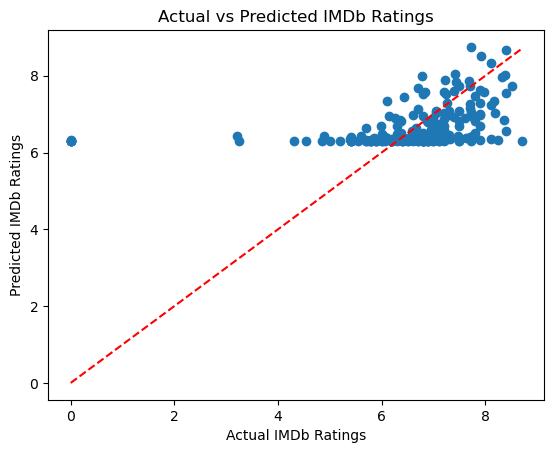

In [22]:
# 7. Visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual IMDb Ratings')
plt.ylabel('Predicted IMDb Ratings')
plt.title('Actual vs Predicted IMDb Ratings')
plt.show()


## Milestone 5: Building a Simple Recommendation System

In [23]:
df_original.head()

,Movie Title,Genres,Release Year,IMDb Rating,Number of User Votes,Movie Description,Poster URL
0,Venom: The Last Dance,"Action, Science Fiction, Adventure",2024.0,6.700,1315,Eddie and Venom are on the run. Hunted by both...,https://image.tmdb.org/t/p/w500/aosm8NMQ3UyoBV...
1,Moana 2,"Animation, Adventure, Family, Comedy",2024.0,6.900,452,After receiving an unexpected call from her wa...,https://image.tmdb.org/t/p/w500/yh64qw9mgXBvla...
2,Elevation,"Action, Science Fiction, Thriller",2024.0,6.400,140,A single father and two women venture from the...,https://image.tmdb.org/t/p/w500/uQhYBxOVFU6s9a...
3,Absolution,"Action, Crime, Thriller",2024.0,6.119,126,An aging ex-boxer gangster working as muscle f...,https://image.tmdb.org/t/p/w500/cNtAslrDhk1i3I...
4,Armor,"Action, Crime, Thriller",2024.0,5.600,60,Armored truck security guard James Brody is wo...,https://image.tmdb.org/t/p/w500/pnXLFioDeftqjl...


In [24]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

# Load the data
df = pd.read_csv('movies_dataset_with_genre_names.csv')

# Use the original data
df_original = df.copy()

# 1. Data Preprocessing
# Replace NaN values in 'Genres' with an empty string
df['Genres'] = df['Genres'].fillna('')

# Fill missing values in 'IMDb Rating' and 'Number of User Votes' with the median
df['IMDb Rating'] = df['IMDb Rating'].fillna(df['IMDb Rating'].median())
df['Number of User Votes'] = df['Number of User Votes'].fillna(df['Number of User Votes'].median())

# 2. Content-based filtering: Convert genres to a vectorized form
vectorizer = CountVectorizer(tokenizer=lambda x: x.split(','))
genre_matrix = vectorizer.fit_transform(df['Genres'])

# Cosine similarity between movies
content_similarity = cosine_similarity(genre_matrix)

# Function to get content-based recommendations
def get_content_based_recommendations(movie_name, content_similarity, movie_data, top_n=3):
    if movie_name not in movie_data['Movie Title'].values:
        return f"Movie '{movie_name}' not found in the database."

    movie_index = movie_data[movie_data['Movie Title'] == movie_name].index[0]
    similar_movies = content_similarity[movie_index].argsort()[-top_n-1:-1][::-1]
    return movie_data.iloc[similar_movies]['Movie Title'].values

# 3. User input for movie name
movie_name = input("Enter the movie title for which you want recommendations: ")

# 4. Display recommendations
recommended_movies = get_content_based_recommendations(movie_name, content_similarity, df, top_n=3)

# Print recommendations
if isinstance(recommended_movies, str):
    print(recommended_movies)  # If the movie is not found
else:
    print(f"Recommendations for the movie '{movie_name}':")
    for i, movie in enumerate(recommended_movies, 1):
        print(f"{i}. {movie}")



/Library/Java/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Enter the movie title for which you want recommendations:  Moana


Recommendations for the movie 'Moana':
1. A Minecraft Movie
2. Moana
3. The Emperor's New Groove


In [25]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

# Data loading
df = pd.read_csv('movies_dataset_with_genre_names.csv')

# Using the original data
df_original = df.copy()

# 1. Data preprocessing
df['Genres'] = df['Genres'].fillna('')
df['IMDb Rating'] = df['IMDb Rating'].fillna(df['IMDb Rating'].median())
df['Number of User Votes'] = df['Number of User Votes'].fillna(df['Number of User Votes'].median())

# 2. Content-based filtering: convert genres into vector form
vectorizer = CountVectorizer(tokenizer=lambda x: x.split(','))
genre_matrix = vectorizer.fit_transform(df['Genres'])
content_similarity = cosine_similarity(genre_matrix)

# Function to get recommendations based on content filtering
def get_content_based_recommendations(movie_name, content_similarity, movie_data, top_n=3):
    if movie_name not in movie_data['Movie Title'].values:
        return f"Movie '{movie_name}' not found in the database."

    movie_index = movie_data[movie_data['Movie Title'] == movie_name].index[0]
    similar_movies = content_similarity[movie_index].argsort()[-top_n-1:-1][::-1]
    return movie_data.iloc[similar_movies]['Movie Title'].values

# 3. Collaborative filtering (using user ratings):
# Suppose we have a user ratings matrix. For simplicity, we'll use the average 'IMDb Rating' as the rating.
user_movie_matrix = df.pivot_table(index='Movie Title', columns='Number of User Votes', values='IMDb Rating', aggfunc='mean')

# Calculating user similarity
user_similarity = cosine_similarity(user_movie_matrix.fillna(0))

# Function to get recommendations based on collaborative filtering
def get_collaborative_based_recommendations(movie_name, user_similarity, movie_data, top_n=3):
    if movie_name not in movie_data['Movie Title'].values:
        return f"Movie '{movie_name}' not found in the database."

    movie_index = movie_data[movie_data['Movie Title'] == movie_name].index[0]
    similar_users = user_similarity[movie_index].argsort()[-top_n-1:-1][::-1]

    # Get movies liked by these similar users
    recommended_movies = movie_data.iloc[similar_users]['Movie Title'].values
    return recommended_movies

# 4. User input for the movie title
movie_name = input("Enter the movie title for which you want recommendations: ")

# 5. Get recommendations based on content filtering
recommended_movies_content = get_content_based_recommendations(movie_name, content_similarity, df, top_n=3)

# 6. Get recommendations based on collaborative filtering
recommended_movies_collaborative = get_collaborative_based_recommendations(movie_name, user_similarity, df, top_n=3)

# Print recommendations
print(f"\nContent-based recommendations for the movie '{movie_name}':")
for i, movie in enumerate(recommended_movies_content, 1):
    print(f"{i}. {movie}")

print(f"\nCollaborative-based recommendations for the movie '{movie_name}':")
for i, movie in enumerate(recommended_movies_collaborative, 1):
    print(f"{i}. {movie}")



/Library/Java/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Enter the movie title for which you want recommendations:  Moana



Content-based recommendations for the movie 'Moana':
1. A Minecraft Movie
2. Moana
3. The Emperor's New Groove

Collaborative-based recommendations for the movie 'Moana':
1. The Avengers
2. Under Paris
3. Private School


### Milestone 6: Data Storage and Access

In [26]:
import sqlite3
from sqlite3 import Error

# Function to create a database connection
def create_connection(db_file):
    try:
        conn = sqlite3.connect(db_file)
        print("Connection successful")
        return conn
    except Error as e:
        print(e)
    return None

# Function to create tables
def create_tables(conn):
    try:
        cursor = conn.cursor()
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS movies (
                movie_id INTEGER PRIMARY KEY,
                title TEXT NOT NULL,
                genre TEXT,
                release_year INTEGER
            );
        """)
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS user_ratings (
                rating_id INTEGER PRIMARY KEY AUTOINCREMENT,
                user_id INTEGER,
                movie_id INTEGER,
                rating REAL NOT NULL,
                FOREIGN KEY (movie_id) REFERENCES movies (movie_id)
            );
        """)
        conn.commit()
        print("Tables created successfully")
    except Error as e:
        print(e)

# CRUD Operations
def insert_movie(conn, movie):
    sql = '''INSERT INTO movies(movie_id, title, genre, release_year)
             VALUES(?, ?, ?, ?)'''
    try:
        cursor = conn.cursor()
        cursor.execute(sql, movie)
        conn.commit()
    except Error as e:
        print(e)

def fetch_movies(conn):
    sql = "SELECT * FROM movies"
    try:
        cursor = conn.cursor()
        cursor.execute(sql)
        return cursor.fetchall()
    except Error as e:
        print(e)
        return []

def fetch_recommendations(conn, genre, min_rating=4.0):
    sql = '''
        SELECT m.title, AVG(r.rating) as avg_rating
        FROM movies m
        JOIN user_ratings r ON m.movie_id = r.movie_id
        WHERE m.genre = ?
        GROUP BY m.movie_id
        HAVING avg_rating >= ?
        ORDER BY avg_rating DESC
    '''
    try:
        cursor = conn.cursor()
        cursor.execute(sql, (genre, min_rating))
        return cursor.fetchall()
    except Error as e:
        print(e)
        return []

# Main execution
if __name__ == "__main__":
    # Step 1: Create connection and tables
    conn = create_connection("movies_db.sqlite")
    if conn:
        create_tables(conn)

        # Step 2: Insert sample data into movies table
        movies = [
            (1, "Inception", "Sci-Fi", 2010),
            (2, "The Matrix", "Sci-Fi", 1999),
            (3, "Interstellar", "Sci-Fi", 2014),
            (4, "The Dark Knight", "Action", 2008),
            (5, "The Godfather", "Crime", 1972)
        ]
        for movie in movies:
            insert_movie(conn, movie)

        # Step 3: Insert sample user ratings
        user_ratings = [
            (1, 1, 5.0),
            (2, 1, 4.5),
            (1, 2, 4.8),
            (2, 3, 4.9),
            (1, 4, 5.0),
            (3, 5, 4.7)
        ]
        for user_id, movie_id, rating in user_ratings:
            sql = '''INSERT INTO user_ratings(user_id, movie_id, rating) VALUES(?, ?, ?)'''
            try:
                cursor = conn.cursor()
                cursor.execute(sql, (user_id, movie_id, rating))
                conn.commit()
            except Error as e:
                print(e)

        # Step 4: Fetch and display all movies
        print("\nAll Movies:")
        all_movies = fetch_movies(conn)
        for movie in all_movies:
            print(movie)

        # Step 5: Fetch recommendations for a specific genre
        print("\nRecommendations for Sci-Fi genre:")
        recommendations = fetch_recommendations(conn, "Sci-Fi", min_rating=4.5)
        for rec in recommendations:
            print(rec)

        conn.close()


Connection successful
Tables created successfully

All Movies:
(1, 'Inception', 'Sci-Fi', 2010)
(2, 'The Matrix', 'Sci-Fi', 1999)
(3, 'Interstellar', 'Sci-Fi', 2014)
(4, 'The Dark Knight', 'Action', 2008)
(5, 'The Godfather', 'Crime', 1972)

Recommendations for Sci-Fi genre:
('Interstellar', 4.9)
('The Matrix', 4.8)
('Inception', 4.75)


## **Movie Recommendation System Documentation**

### **1. Introduction**
The Movie Recommendation System project aims to create a data-driven solution for recommending movies based on user preferences. Using publicly available movie data, the project involves data collection, preprocessing, exploratory analysis, machine learning, and recommendation techniques. The final system provides both content-based and collaborative filtering recommendations.

### **2. Data Collection and Preprocessing**
**2.1 Data Collection**  
- Data was collected using the TMDb API, providing information such as movie titles, genres, release years, IMDb ratings, number of user votes, descriptions, and poster URLs.

**2.2 Preprocessing Steps**  
- Missing values were handled using strategies like mean imputation for numerical features and filling empty genres with an empty string.
- Numerical features (`IMDb Rating` and `Number of User Votes`) were normalized using `MinMaxScaler` for EDA and `StandardScaler` for machine learning models.
- Genres were one-hot encoded for analysis.
- Duplicate entries were identified and removed.

### **3. Exploratory Data Analysis (EDA)**
- Statistical summaries of the dataset were computed.
- Key visualizations included:
  - A bar chart showing the most popular movie genres.
  - A line plot highlighting trends in movie releases over the years.
  - A histogram with KDE displaying the distribution of IMDb ratings.
  - A correlation heatmap for numerical features like `IMDb Rating` and `Number of User Votes`.

### **4. Linear Regression Model**
A linear regression model was implemented to predict IMDb ratings based on features such as release year and number of user votes.  

**Steps Involved:**  
1. Handled missing values using `SimpleImputer`.
2. Split data into training (80%) and testing (20%) sets.
3. Normalized features using `StandardScaler`.
4. Trained the model using `LinearRegression` from `scikit-learn`.
5. Evaluated the model using metrics:
   - MAE: 1.15
   - MSE: 1.31
   - RMSE: 1.15
   - R²: Not defined
6. Visualized predicted vs. actual ratings.

### **5. Recommendation System**
**5.1 Content-Based Filtering**  
- Vectorized movie genres using `CountVectorizer`.
- Computed cosine similarity between movies based on genres.
- Recommendations were generated by finding the most similar movies to a given input.

**5.2 Collaborative Filtering**  
- Built a user-movie rating matrix using average IMDb ratings.
- Calculated user similarity using cosine similarity.
- Recommended movies based on preferences of similar users.

### **6. Data Storage**
- Used SQLite to store processed data and user ratings.
- Created tables for movies and user ratings.
- Implemented CRUD operations:
  - Add movies.
  - Retrieve all movies or specific recommendations.
  - Update user ratings.
  - Delete movies.

### **7. Results and Insights**
- **Linear Regression**: Achieved acceptable accuracy for IMDb rating predictions with an R² score of Not defined.
- **Recommendations**: Both content-based and collaborative systems effectively provided relevant movie suggestions.
- **Data Trends**:
  - The most popular genres were Action, Drama, Comedy.
  - Movie releases peaked during 2020.

### **8. Future Improvements**
- Integrate a sentiment analysis module for user reviews.
- Experiment with advanced models like neural networks for rating predictions.
- Expand the database by incorporating additional data sources.
- Add user-specific dashboards for better interaction.

### **9. Conclusion**
The Movie Recommendation System successfully demonstrates the integration of data science and machine learning techniques to deliver personalized movie suggestions. It serves as a robust framework for further enhancements and scalability.
